In [1]:
import torch
from src.SD3_custom_pipeline import StableDiffusion3Pipeline

In [2]:
pipe = StableDiffusion3Pipeline.from_pretrained(
    "stabilityai/stable-diffusion-3-medium-diffusers",
    torch_dtype=torch.float16
)
pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


StableDiffusion3Pipeline {
  "_class_name": "StableDiffusion3Pipeline",
  "_diffusers_version": "0.35.1",
  "_name_or_path": "stabilityai/stable-diffusion-3-medium-diffusers",
  "feature_extractor": [
    null,
    null
  ],
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "text_encoder_3": [
    "transformers",
    "T5EncoderModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_3": [
    "transformers",
    "T5TokenizerFast"
  ],
  "transformer": [
    "diffusers",
    "SD3Transformer2DModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/10 [00:00<?, ?it/s]

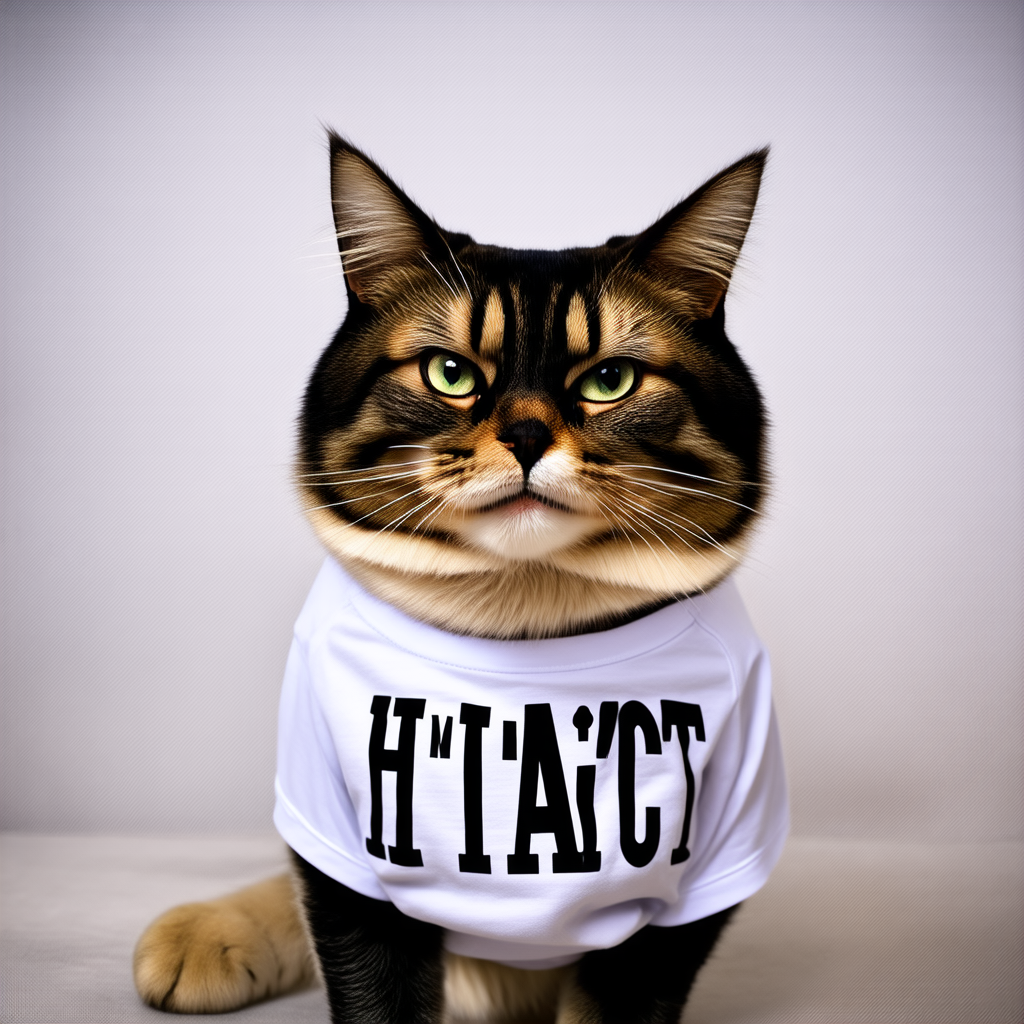

In [ ]:
pipe.layer_weights= [1.,1.,1.,3.,1.]
pipe.skipped_layers=[4,5,10,13,15]
pipe.multiskip = True
pipe.layer_search=False
pipe.patch_prompt='A crazy cat wearing a shirt that says "HI IM CAT"'
image = pipe(
    prompt='A crazy cat wearing a shirt without any print',
    num_inference_steps=10,
    skip_layer_guidance_scale=2.5, 
    guidance_scale=9.0,
    generator=torch.Generator("cpu").manual_seed(42),
    skip_guidance_layers=[4,5,10,13,15],
    skip_layer_guidance_start=1.,
    skip_layer_guidance_stop=1.
).images[0]
image

  0%|          | 0/30 [00:00<?, ?it/s]

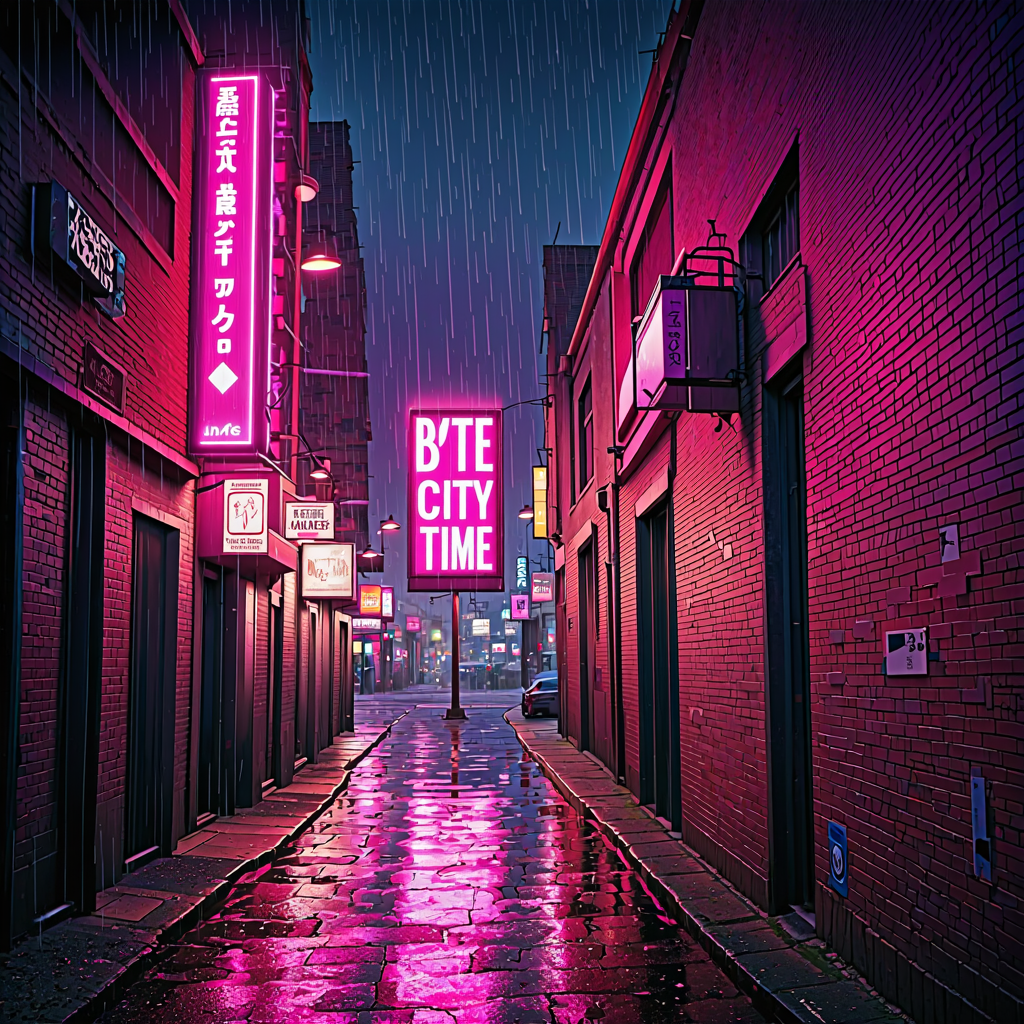

In [14]:
pipe.layer_weights= [1.,1.,1.,1.,1.,1.]
pipe.multiskip = True
pipe.layer_search=False
pipe.patch_prompt="A neon-soaked alley at midnight. A towering billboard on the brick wall reads 'BYTE CITY TIME' in blinding magenta light, rain streaks shimmering below."
image = pipe(
    prompt=pipe.patch_prompt,
    num_inference_steps=30,
    skip_layer_guidance_scale=2., 
    generator=torch.Generator("cpu").manual_seed(42),
    skip_guidance_layers=[24,12,23,5,6,7],
    guidance_scale=5.,
    skip_layer_guidance_start=0.1,
    skip_layer_guidance_stop=1.
).images[0]
image

  0%|          | 0/30 [00:00<?, ?it/s]

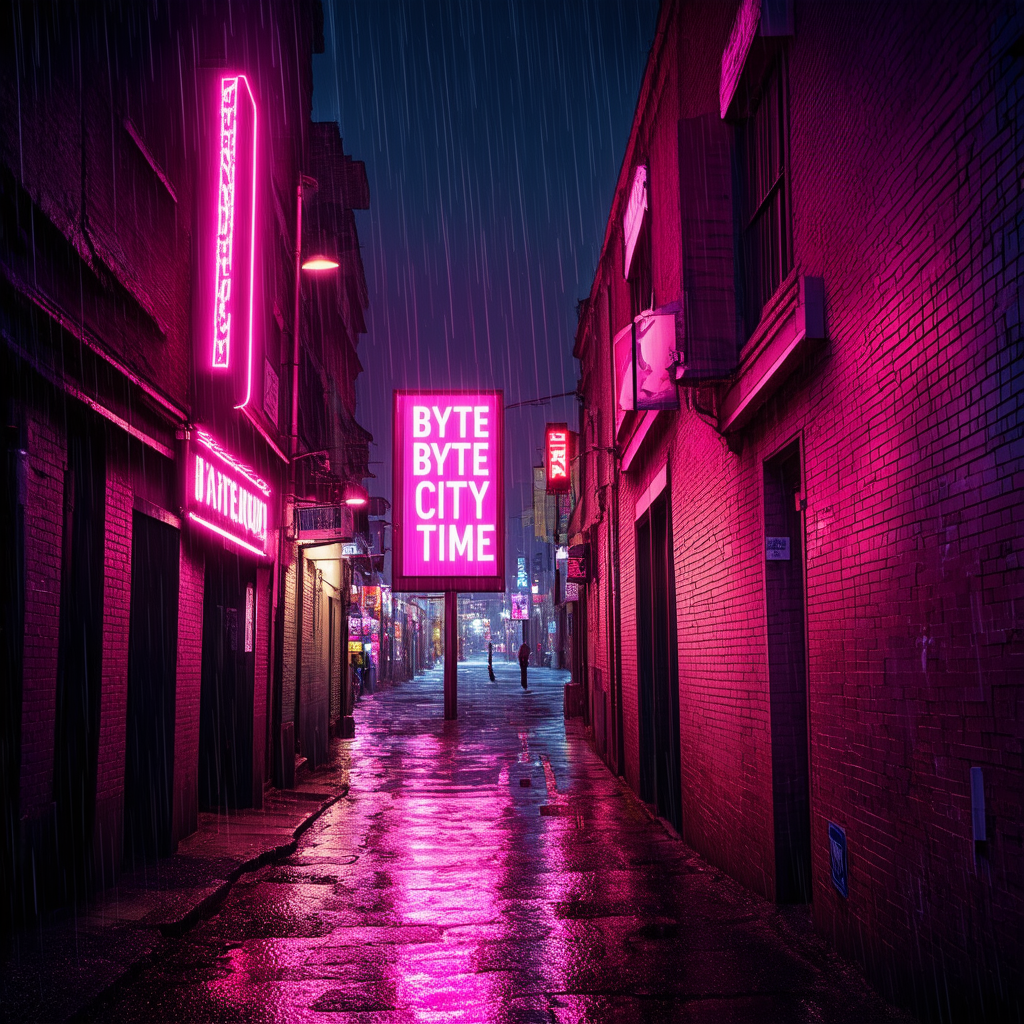

In [13]:
pipe.layer_weights= [1.]
pipe.skipped_layers=[13]
pipe.multiskip = True
pipe.layer_search=False
pipe.patch_prompt="A neon-soaked alley at midnight. A towering billboard on the brick wall reads 'BYTE CITY TIME' in blinding magenta light, rain streaks shimmering below."
image = pipe(
    prompt=pipe.patch_prompt,
    num_inference_steps=30,
    skip_layer_guidance_scale=2.0, 
    generator=torch.Generator("cpu").manual_seed(42),
    skip_guidance_layers=[13],
    guidance_scale=7.,
    skip_layer_guidance_start=1.,
    skip_layer_guidance_stop=1.
).images[0]
image